In [1]:
import yfinance as yf
import pandas as pd

# 1. Define the tickers and download the data
tickers = ["AAPL", "SPY"]
raw_data = yf.download(tickers, start="2020-01-01")

# 2. Extract and store the closing prices
closing_prices = raw_data['Close']

# 3. Clean the data by handling missing values
clean_prices = closing_prices.dropna()

# Display the first 5 rows to confirm it worked
print(clean_prices.head())

/Users/gustavo/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  2 of 2 completed

Ticker           AAPL         SPY
Date                             
2020-01-02  72.333855  296.888123
2020-01-03  71.630653  294.640076
2020-01-06  72.201416  295.764099
2020-01-07  71.861839  294.932617
2020-01-08  73.017853  296.504333


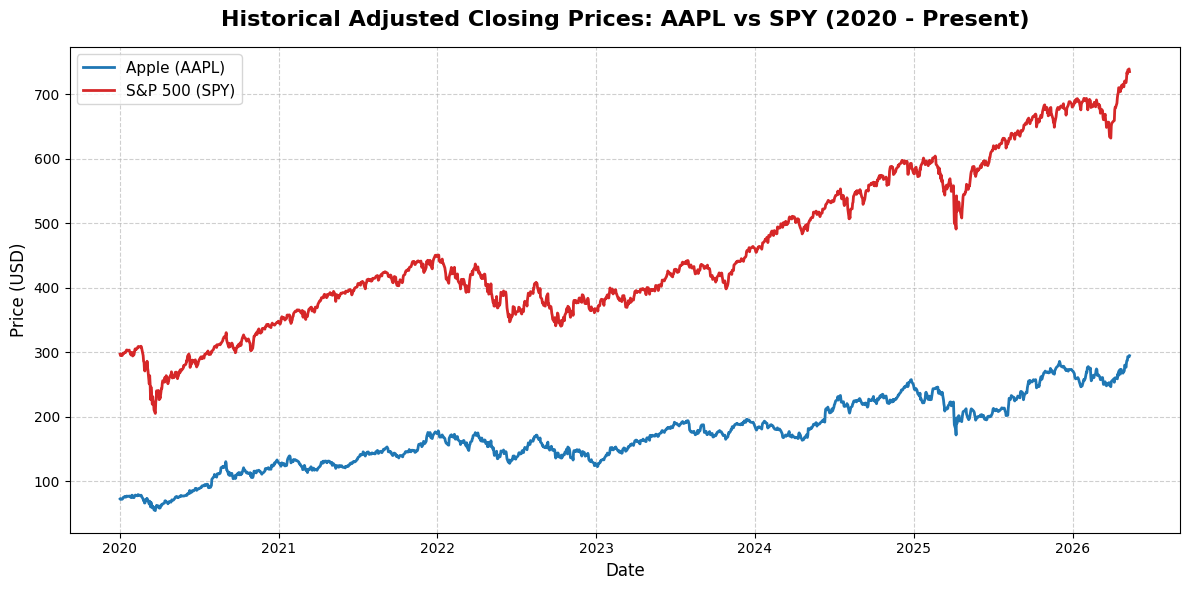

In [2]:
import matplotlib.pyplot as plt

# 1. Set the figure size (the "canvas")
plt.figure(figsize=(12, 6))

# 2. Plot the data lines
# The DataFrame's index (dates) is automatically used for the X-axis
plt.plot(clean_prices.index, clean_prices['AAPL'], label='Apple (AAPL)', color='#1f77b4', linewidth=2)
plt.plot(clean_prices.index, clean_prices['SPY'], label='S&P 500 (SPY)', color='#d62728', linewidth=2)

# 3. Add titles and labels
plt.title('Historical Adjusted Closing Prices: AAPL vs SPY (2020 - Present)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

# 4. Add the legend
plt.legend(loc='upper left', fontsize=11)

# 5. Add a grid for a clean, professional look
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Display the plot
plt.tight_layout() # Ensures everything fits without getting cut off
plt.show()

In [3]:
# 1. Calculate the daily percentage change
daily_returns = clean_prices.pct_change()

# 2. Handle the NaN values properly
daily_returns = daily_returns.dropna()

# Display the first few rows to verify
print(daily_returns.head())

Ticker          AAPL       SPY
Date                          
2020-01-03 -0.009722 -0.007572
2020-01-06  0.007968  0.003815
2020-01-07 -0.004703 -0.002811
2020-01-08  0.016087  0.005329
2020-01-09  0.021240  0.006781


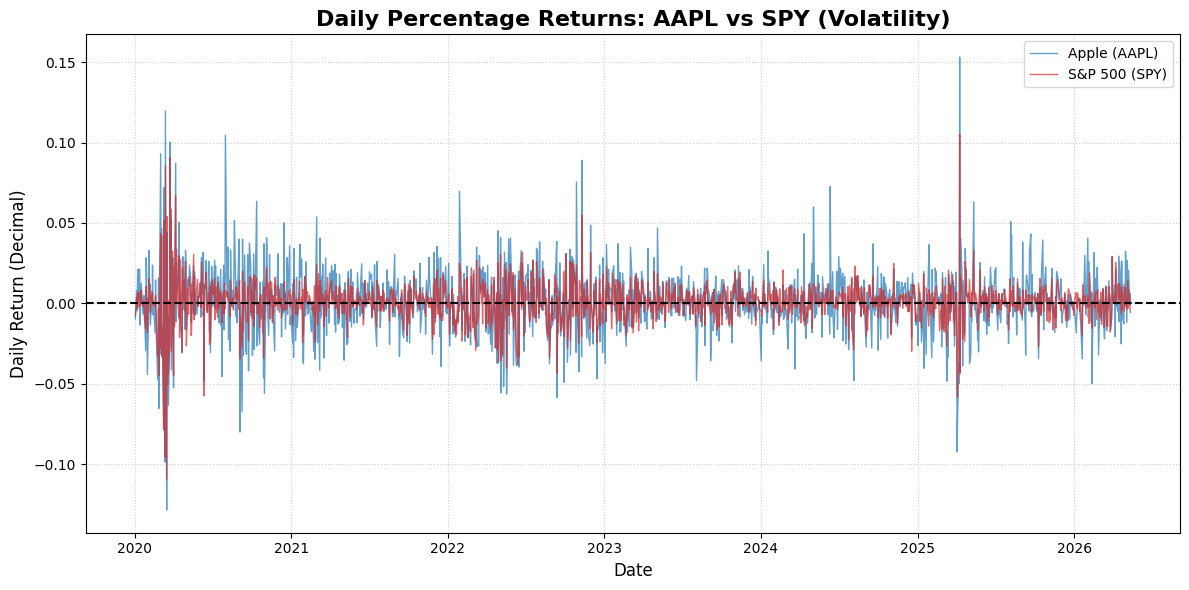

In [4]:
import matplotlib.pyplot as plt

# 1. Set up the canvas
plt.figure(figsize=(12, 6))

# 2. Plot the daily returns
# We use alpha=0.7 to make the lines slightly transparent so we can see where they overlap
plt.plot(daily_returns.index, daily_returns['AAPL'], label='Apple (AAPL)', color='#1f77b4', linewidth=1, alpha=0.7)
plt.plot(daily_returns.index, daily_returns['SPY'], label='S&P 500 (SPY)', color='#d62728', linewidth=1, alpha=0.7)

# 3. Add titles and labels
plt.title('Daily Percentage Returns: AAPL vs SPY (Volatility)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Return (Decimal)', fontsize=12)

# 4. Add a horizontal line at 0 (the break-even line)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

# 5. Clean up and display
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Final Value of a $1 Investment:
Ticker          AAPL       SPY
Date                          
2026-05-12  4.071123  2.476101
------------------------------


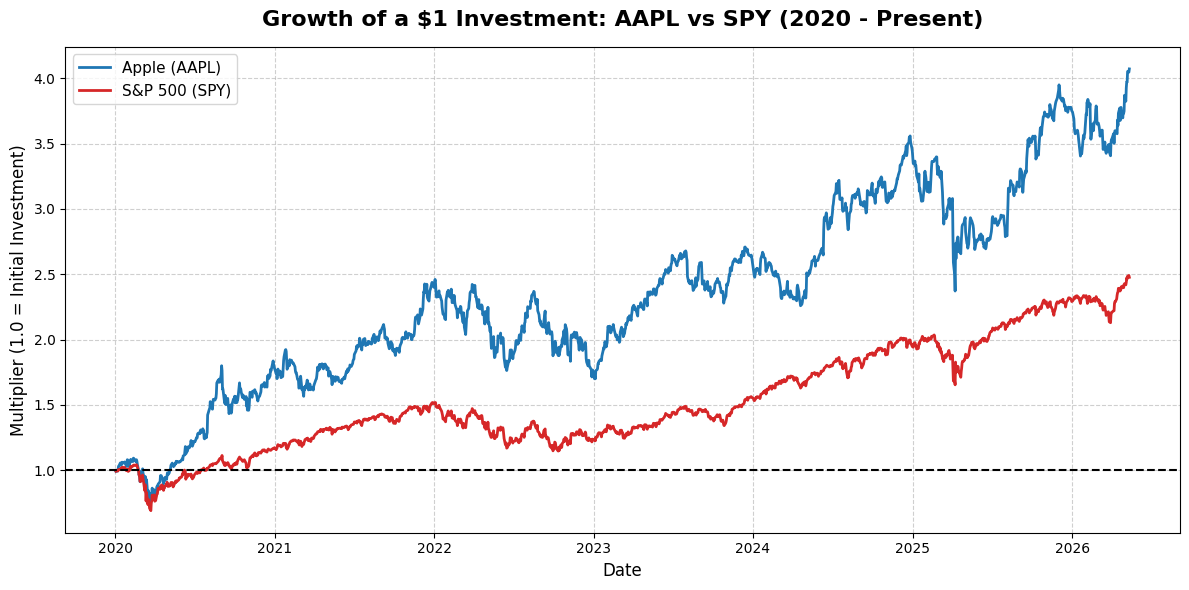

In [5]:
import matplotlib.pyplot as plt

# 1. Calculate Cumulative Returns
# We add 1 to the daily returns, then use .cumprod() to snowball them.
cumulative_returns = (1 + daily_returns).cumprod()

# Display the last few rows to see the final "score"
print("Final Value of a $1 Investment:")
print(cumulative_returns.tail(1))
print("-" * 30)

# 2. Visualize the Cumulative Growth
plt.figure(figsize=(12, 6))

# Plot the lines
plt.plot(cumulative_returns.index, cumulative_returns['AAPL'], label='Apple (AAPL)', color='#1f77b4', linewidth=2)
plt.plot(cumulative_returns.index, cumulative_returns['SPY'], label='S&P 500 (SPY)', color='#d62728', linewidth=2)

# 3. Add titles and labels
plt.title('Growth of a $1 Investment: AAPL vs SPY (2020 - Present)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Multiplier (1.0 = Initial Investment)', fontsize=12)

# 4. Add a baseline
# A horizontal line at Y=1.0 represents your starting money ($1)
plt.axhline(1.0, color='black', linewidth=1.5, linestyle='--')

# 5. Clean up and display
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [6]:
import pandas as pd
import numpy as np

# 1. Calculate Average Daily Return
# .mean() calculates the average of all the daily percentage changes
avg_daily_return = daily_returns.mean()

# 2. Calculate Annualized Return
# We multiply by 252 because there are roughly 252 trading days in a year
annualized_return = avg_daily_return * 252

# 3. Calculate Annualized Volatility (Standard Deviation)
# We multiply the daily standard deviation by the square root of 252
annualized_volatility = daily_returns.std() * np.sqrt(252)

# 4. Build a Professional Summary Table
# We use a Python dictionary to organize our calculated metrics into columns
summary_data = {
    'Avg Daily Return': avg_daily_return,
    'Annualized Return': annualized_return,
    'Annualized Volatility': annualized_volatility
}

summary_table = pd.DataFrame(summary_data)

# 5. Format the table for professional presentation
# .style.format makes the raw decimals look like clean percentages (e.g., 0.254 -> 25.40%)
formatted_table = summary_table.style.format("{:.2%}")

# Display the table
formatted_table

,Avg Daily Return,Annualized Return,Annualized Volatility
Ticker,,,
AAPL,0.11%,27.09%,31.46%
SPY,0.07%,16.40%,20.42%


In [13]:
import pandas as pd
import yfinance as yf
import requests # NEW: We need this to send our "disguise"
import numpy as np

print("Fetching latest S&P 500 tickers from Wikipedia...")

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# 1. THE DISGUISE: We tell Wikipedia we are Google Chrome on a Windows PC
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# 2. Fetch the webpage using our disguise
response = requests.get(url, headers=headers)

# 3. Hand the raw HTML text over to pandas to find the tables
tables = pd.read_html(response.text)

# Grab the first table and extract the 'Symbol' column
sp500_df = tables[0]
tickers = sp500_df['Symbol'].tolist()

# Clean the data (yfinance uses '-' instead of '.' for stocks like BRK.B)
tickers = [ticker.replace('.', '-') for ticker in tickers]

print(f"Successfully loaded {len(tickers)} tickers.")

# Let's just grab the first 5 so you don't wait forever while testing!
tickers_to_test = tickers[:5]

stock_metrics = {}
historical_prices = pd.DataFrame() 

# NEW: Define the Risk-Free Rate (e.g., 4% / 0.04)
risk_free_rate = 0.04

for ticker in tickers_to_test:
    print(f"Processing {ticker}...")
    
    # Download data silently
    raw_data = yf.download(ticker, start="2020-01-01", progress=False)
    
    # Extract the raw 1D prices
    clean_prices = raw_data['Close'].squeeze().dropna()
    historical_prices[ticker] = clean_prices
    
    # Calculate metrics
    daily_returns = clean_prices.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    
    # NEW: Calculate the Sharpe Ratio
    sharpe_ratio = (ann_return - risk_free_rate) / ann_vol
    
    # Store metrics
    stock_metrics[ticker] = {
        'Annualized Return': ann_return,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe_ratio # NEW: Added to the filing cabinet
    }

print("\nAll stocks processed successfully!")

# Build and format the final summary table
summary_table = pd.DataFrame(stock_metrics).T

# NEW: Advanced Formatting to handle the Sharpe float and the return percentages
formatted_table = summary_table.style.format({
    'Annualized Return': "{:.2%}",
    'Annualized Volatility': "{:.2%}",
    'Sharpe Ratio': "{:.2f}"
})

# Display the final dashboard
formatted_table

Fetching latest S&P 500 tickers from Wikipedia...


/var/folders/3d/mp4cptns6d509v51bjhgm4t80000gn/T/ipykernel_84251/1869265096.py:19: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Successfully loaded 503 tickers.
Processing MMM...
Processing AOS...
Processing ABT...
Processing ABBV...
Processing ACN...

All stocks processed successfully!


,Annualized Return,Annualized Volatility,Sharpe Ratio
MMM,6.98%,29.51%,0.10
AOS,9.14%,29.31%,0.18
ABT,4.56%,25.71%,0.02
ABBV,20.67%,25.10%,0.66
ACN,3.01%,30.23%,-0.03


In [9]:
stock_metrics = {}

In [15]:
import pandas as pd
import yfinance as yf
import numpy as np

# 1. Define your universe of stocks
tickers = ["AAPL", "MSFT", "NVDA", "JPM", "WMT", "SPY","PETR4.SA"]
stock_metrics = {}
risk_free_rate = 0.04

print("Fetching data and calculating metrics...")

# 2. The Data Engine
for ticker in tickers:
    # Download and clean
    raw_data = yf.download(ticker, start="2020-01-01", progress=False)
    clean_prices = raw_data['Close'].squeeze().dropna()
    
    # Calculate daily returns
    daily_returns = clean_prices.pct_change().dropna()
    
    # Calculate core metrics
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe_ratio = (ann_return - risk_free_rate) / ann_vol
    
    # Store in dictionary
    stock_metrics[ticker] = {
        'Annualized Return': ann_return,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe_ratio
    }

print("Ranking stocks...")

# 3. Build the DataFrame
summary_table = pd.DataFrame(stock_metrics).T

# --- NEW RANKING LOGIC ---
# We use .rank() to assign a position (1 is the best)
# ascending=False means the highest number gets Rank 1
summary_table['Return Rank'] = summary_table['Annualized Return'].rank(ascending=False)

# ascending=True means the LOWEST volatility gets Rank 1 (safest)
summary_table['Safety Rank'] = summary_table['Annualized Volatility'].rank(ascending=True) 

summary_table['Sharpe Rank'] = summary_table['Sharpe Ratio'].rank(ascending=False)

# 4. Sort the table by the ultimate metric: Sharpe Ratio
ranked_table = summary_table.sort_values(by='Sharpe Ratio', ascending=False)

# 5. Format for professional presentation
formatted_table = ranked_table.style.format({
    'Annualized Return': "{:.2%}",
    'Annualized Volatility': "{:.2%}",
    'Sharpe Ratio': "{:.2f}",
    'Return Rank': "#{:.0f}",
    'Safety Rank': "#{:.0f}",
    'Sharpe Rank': "#{:.0f}"
}).background_gradient(subset=['Sharpe Ratio'], cmap='Greens')

# Display the sorted, color-coded table
display(formatted_table)

Fetching data and calculating metrics...
Ranking stocks...


,Annualized Return,Annualized Volatility,Sharpe Ratio,Return Rank,Safety Rank,Sharpe Rank
NVDA,70.32%,52.38%,1.27,#1,#7,#1
WMT,22.85%,23.14%,0.81,#4,#2,#2
PETR4.SA,35.21%,41.21%,0.76,#2,#6,#3
AAPL,27.06%,31.45%,0.73,#3,#5,#4
SPY,16.35%,20.42%,0.60,#7,#1,#5
MSFT,19.98%,29.72%,0.54,#5,#3,#6
JPM,19.48%,31.03%,0.50,#6,#4,#7


In [17]:
import pandas as pd
import yfinance as yf
import numpy as np
%pip install tqdm finvizfinance
from tqdm import tqdm
from finvizfinance.screener.overview import Overview

# --- STEP 1: SERVER-SIDE SCREENING (FINVIZ) ---
print("1. Asking Finviz to find top performing S&P 500 stocks...")
foverview = Overview()

# Filter: We only want S&P 500 stocks that are up at least 20% this year.
# This instantly eliminates hundreds of bad or sideways stocks.
filters_dict = {
    'Index': 'S&P 500',
    'Performance': 'Year +20%'
}
foverview.set_filter(filters_dict=filters_dict)

# Get the results and extract the tickers into a list
filtered_df = foverview.screener_view()
top_tickers = filtered_df['Ticker'].tolist()

print(f"-> Finviz found {len(top_tickers)} stocks matching the criteria.\n")

# --- STEP 2: QUANTITATIVE ANALYSIS (YAHOO FINANCE) ---
print("2. Downloading historical data and calculating Sharpe Ratios...")
stock_metrics = {}
risk_free_rate = 0.04

# Loop through ONLY the winning stocks from Finviz
for ticker in tqdm(top_tickers, desc="Analyzing Stocks"):
    try:
        # Download data silently
        raw_data = yf.download(ticker, start="2020-01-01", progress=False)
        
        if raw_data.empty:
            continue
            
        clean_prices = raw_data['Close'].squeeze().dropna()
        daily_returns = clean_prices.pct_change().dropna()
        
        ann_return = daily_returns.mean() * 252
        ann_vol = daily_returns.std() * np.sqrt(252)
        sharpe_ratio = (ann_return - risk_free_rate) / ann_vol
        
        stock_metrics[ticker] = {
            'Annualized Return': ann_return,
            'Annualized Volatility': ann_vol,
            'Sharpe Ratio': sharpe_ratio
        }
    except Exception:
        # If a ticker has bad data, silently skip it so the program doesn't crash
        pass 

# --- STEP 3: RANKING & DISPLAY ---
print("\n3. Generating Final Report...")
summary_table = pd.DataFrame(stock_metrics).T

# Calculate the ranks
summary_table['Return Rank'] = summary_table['Annualized Return'].rank(ascending=False)
summary_table['Safety Rank'] = summary_table['Annualized Volatility'].rank(ascending=True)
summary_table['Sharpe Rank'] = summary_table['Sharpe Ratio'].rank(ascending=False)

# Sort the entire table so the #1 Sharpe Ratio is at the very top
ranked_table = summary_table.sort_values(by='Sharpe Ratio', ascending=False)

# Format for a professional, dashboard-ready look
formatted_table = ranked_table.style.format({
    'Annualized Return': "{:.2%}",
    'Annualized Volatility': "{:.2%}",
    'Sharpe Ratio': "{:.2f}",
    'Return Rank': "#{:.0f}",
    'Safety Rank': "#{:.0f}",
    'Sharpe Rank': "#{:.0f}"
}).background_gradient(subset=['Sharpe Ratio'], cmap='Greens')

# Display the final output
display(formatted_table)

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [finvizfinance]
Note: you may need to restart the kernel to use updated packages.
1. Asking Finviz to find top performing S&P 500 stocks...
-> Finviz found 175 stocks matching the criteria.--] 8/9 

2. Downloading historical data and calculating Sharpe Ratios...


Analyzing Stocks: 100%|██████████| 175/175 [03:19<00:00,  1.14s/it]


3. Generating Final Report...


,Annualized Return,Annualized Volatility,Sharpe Ratio,Return Rank,Safety Rank,Sharpe Rank
SNDK,348.94%,100.62%,3.43,#1,#174,#1
GEV,112.70%,53.18%,2.04,#2,#150,#2
FIX,69.99%,47.38%,1.39,#6,#137,#3
PWR,53.31%,37.83%,1.30,#13,#93,#4
NVDA,70.40%,52.38%,1.27,#5,#148,#5
VRT,73.22%,60.33%,1.15,#4,#164,#6
STX,53.57%,44.30%,1.12,#12,#123,#7
AVGO,52.33%,43.76%,1.10,#14,#120,#8
EME,44.53%,37.15%,1.09,#26,#89,#9
HWM,47.13%,42.17%,1.02,#24,#115,#10


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


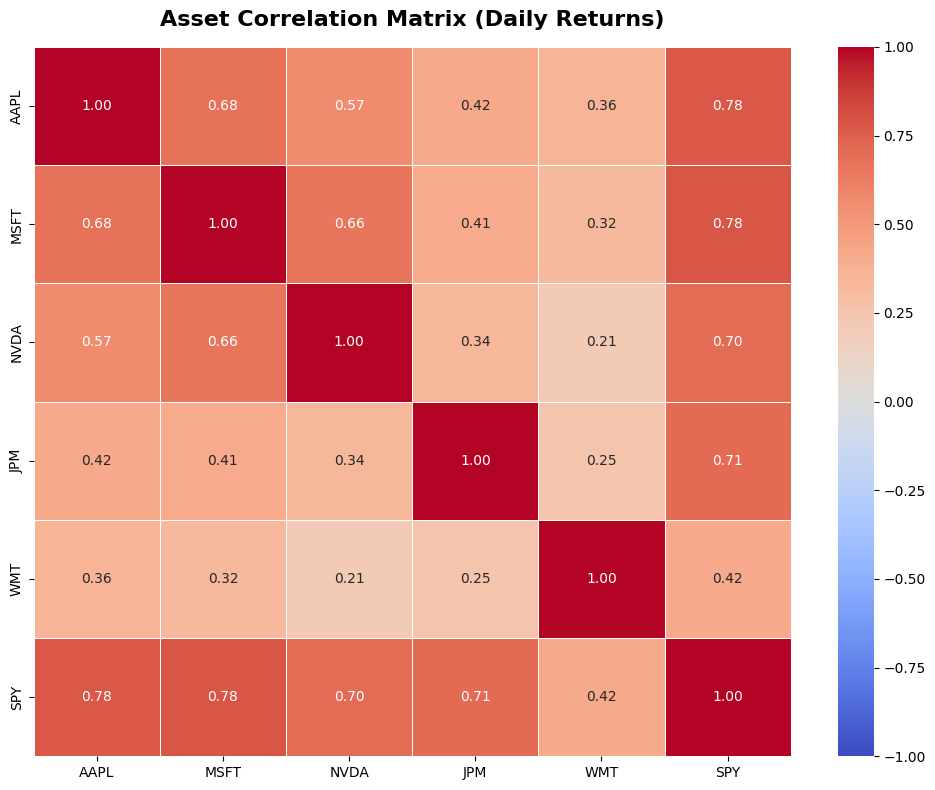

In [19]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns  # NEW: The ultimate library for statistical charts

# 1. Define your tickers (Using the manual list method)
tickers = ["AAPL", "MSFT", "NVDA", "JPM", "WMT", "SPY"]
historical_prices = pd.DataFrame()

print("Downloading data for correlation matrix...")

# 2. Download closing prices
for ticker in tickers:
    raw_data = yf.download(ticker, start="2020-01-01", progress=False)
    historical_prices[ticker] = raw_data['Close'].squeeze().dropna()

# 3. Calculate Daily Returns
# We must correlate RETURNS, not raw prices!
daily_returns = historical_prices.pct_change().dropna()

# 4. Calculate the Correlation Matrix (The Math)
# Pandas does all the complex statistics in one single word:
correlation_matrix = daily_returns.corr()

# 5. Visualize with a Seaborn Heatmap
plt.figure(figsize=(10, 8))

# sns.heatmap automatically reads the pandas matrix and colors it
sns.heatmap(
    correlation_matrix,
    annot=True,          # Prints the actual numbers inside the boxes
    cmap='coolwarm',     # Color palette (blue = cold/negative, red = hot/positive)
    vmin=-1, vmax=1,     # Forces the color scale to lock exactly between -1 and 1
    linewidths=0.5,      # Adds a clean white border between squares
    fmt=".2f"            # Formats the numbers to 2 decimal places
)

# 6. Polish the chart
plt.title("Asset Correlation Matrix (Daily Returns)", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Maximum Drawdown for AAPL: -33.36%



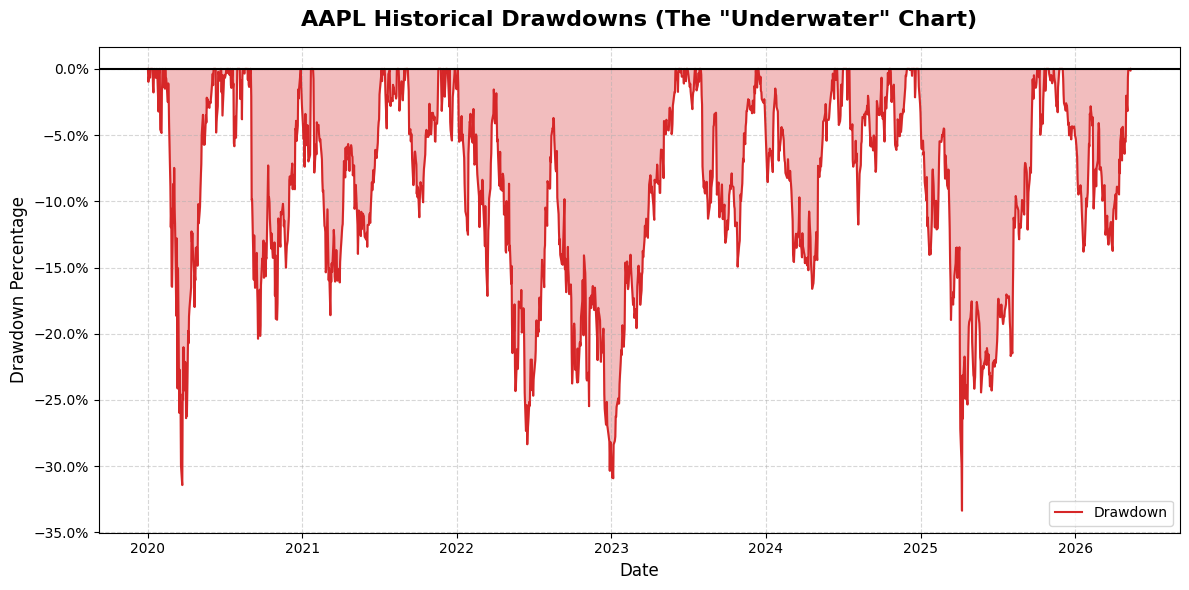

In [20]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Download data for a specific stock (Let's use Apple as an example)
ticker = "AAPL"
print(f"Downloading data for {ticker}...")
data = yf.download(ticker, start="2020-01-01", progress=False)

# Extract the raw closing prices
prices = data['Close'].squeeze().dropna()

# 2. THE DRAWDOWN MATH
# Step A: Calculate the Running Maximum (The highest peak seen so far)
rolling_max = prices.cummax()

# Step B: Calculate the Drawdown percentage
# (Current Price - Peak Price) / Peak Price
drawdown = (prices - rolling_max) / rolling_max

# Step C: Find the Maximum Drawdown (The lowest point in the series)
max_drawdown = drawdown.min()
print(f"Maximum Drawdown for {ticker}: {max_drawdown:.2%}\n")

# 3. VISUALIZATION: The Underwater Chart
plt.figure(figsize=(12, 6))

# Plot the drawdown line
plt.plot(drawdown.index, drawdown, color='#d62728', linewidth=1.5, label='Drawdown')

# Fill the area below 0 to make it look "underwater"
plt.fill_between(drawdown.index, drawdown, 0, color='#d62728', alpha=0.3)

# Add the "surface" line at 0%
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')

# Polish the chart
plt.title(f'{ticker} Historical Drawdowns (The "Underwater" Chart)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Drawdown Percentage', fontsize=12)
plt.xlabel('Date', fontsize=12)

# Format the Y-axis as clean percentages (e.g., -20% instead of -0.2)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()


--- PORTFOLIO RESULTS ---
Expected Annual Return: 23.49%
Annualized Volatility:  20.11%
Sharpe Ratio (assumes 4% RF): 0.97


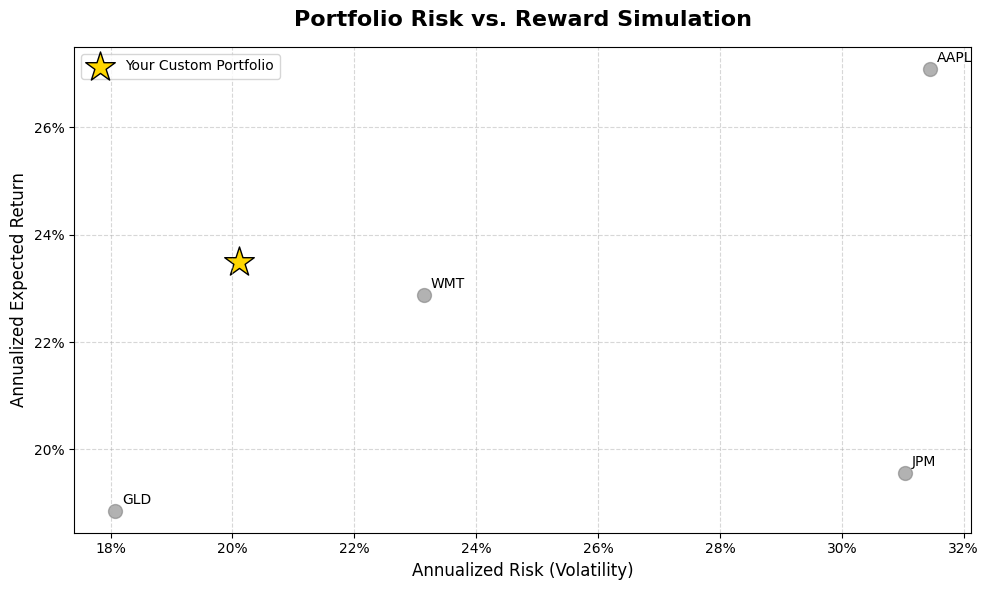

In [21]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINE YOUR PORTFOLIO
# Keys are tickers, values are the target weights (MUST sum to 1.0)
portfolio_weights = {
    "AAPL": 0.40,  # 40% in Tech
    "WMT": 0.30,   # 30% in Retail
    "JPM": 0.20,   # 20% in Banking
    "GLD": 0.10    # 10% in Gold
}

tickers = list(portfolio_weights.keys())
weights_array = np.array(list(portfolio_weights.values()))

# Verify weights equal 100%
if not np.isclose(weights_array.sum(), 1.0):
    print("Warning: Your weights do not sum to 1.0 (100%)!")

print("Downloading data and running simulation...")

# 2. DOWNLOAD & CLEAN DATA
historical_prices = pd.DataFrame()
for ticker in tickers:
    raw_data = yf.download(ticker, start="2020-01-01", progress=False)
    historical_prices[ticker] = raw_data['Close'].squeeze().dropna()

daily_returns = historical_prices.pct_change().dropna()

# 3. CALCULATE METRICS (The Matrix Math)
# Annualize mean returns and the covariance matrix
mean_annual_returns = daily_returns.mean() * 252
cov_matrix_annual = daily_returns.cov() * 252

# Portfolio Return: Weighted average
port_return = np.sum(mean_annual_returns * weights_array)

# Portfolio Volatility: The Matrix Dot Product 
# np.dot multiplies the arrays. We do this twice and take the square root.
port_volatility = np.sqrt(np.dot(weights_array.T, np.dot(cov_matrix_annual, weights_array)))

print("\n--- PORTFOLIO RESULTS ---")
print(f"Expected Annual Return: {port_return:.2%}")
print(f"Annualized Volatility:  {port_volatility:.2%}")
print(f"Sharpe Ratio (assumes 4% RF): {(port_return - 0.04) / port_volatility:.2f}")

# 4. VISUALIZE: Risk vs. Reward Scatter Plot
plt.figure(figsize=(10, 6))

# Plot the individual stocks as gray dots
for ticker in tickers:
    ret = mean_annual_returns[ticker]
    vol = np.sqrt(cov_matrix_annual.loc[ticker, ticker])
    plt.scatter(vol, ret, color='gray', s=100, alpha=0.6)
    plt.annotate(ticker, (vol, ret), xytext=(5, 5), textcoords='offset points', fontsize=10)

# Plot the PORTFOLIO as a giant gold star
plt.scatter(port_volatility, port_return, color='gold', marker='*', s=500, edgecolor='black', label='Your Custom Portfolio')

# Polish the chart
plt.title("Portfolio Risk vs. Reward Simulation", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Annualized Risk (Volatility)", fontsize=12)
plt.ylabel("Annualized Expected Return", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

# Format axes as percentages
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

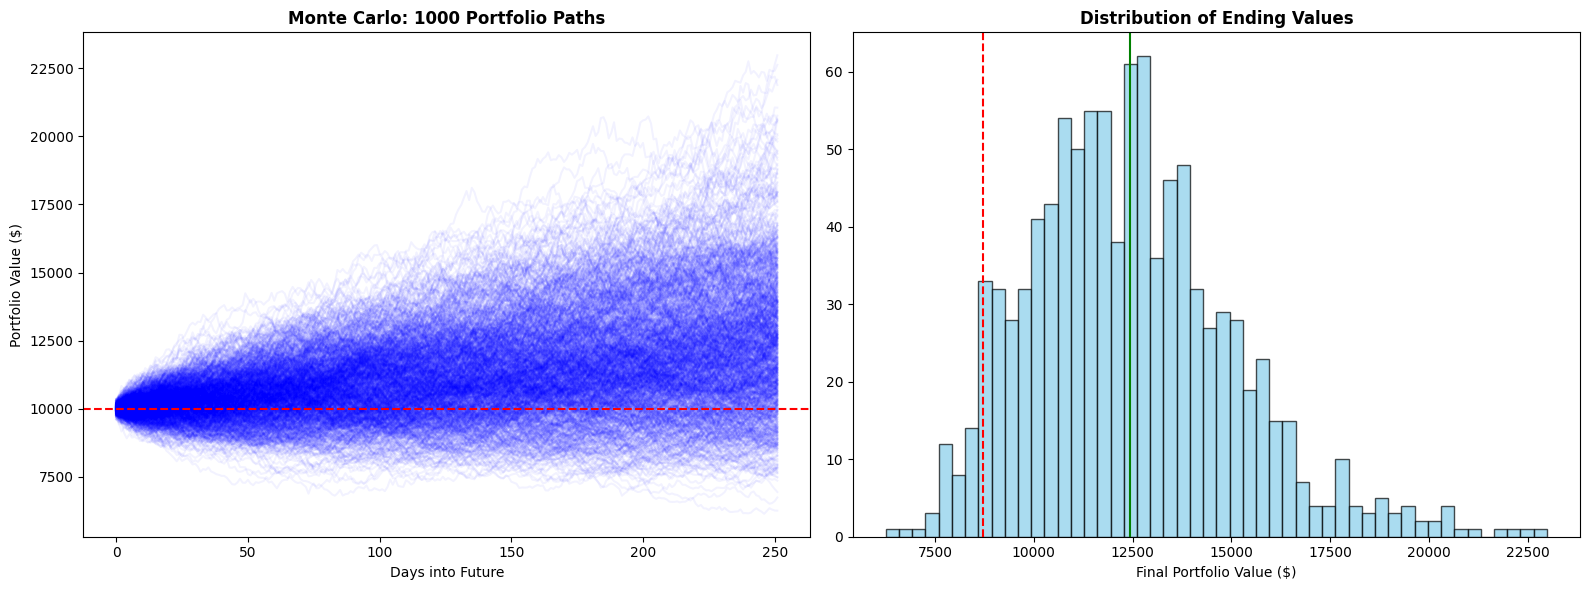

--- SIMULATION RESULTS (1000 runs) ---
Mean Expected Value: $12,441.34
Median Expected Value: $12,259.78
5% Value at Risk (VaR): $1,280.53


In [22]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP PARAMETERS
tickers = ["AAPL", "MSFT", "SPY", "GLD"]
weights = np.array([0.4, 0.3, 0.2, 0.1])
initial_investment = 10000
num_simulations = 1000
forecast_days = 252 # One trading year

# 2. FETCH & PROCESS DATA
data = yf.download(tickers, start="2020-01-01", progress=False)['Close']
returns = data.pct_change().dropna()

# Calculate Mean and Covariance
mean_returns = returns.mean()
cov_matrix = returns.cov()

# 3. MONTE CARLO SIMULATION ENGINE
# Pre-calculate portfolio mean and volatility
port_mean = np.sum(mean_returns * weights)
port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

# Create a matrix to store simulation results
# Rows = Days, Columns = Different Simulations
simulation_results = np.zeros((forecast_days, num_simulations))

for i in range(num_simulations):
    # Generate random daily shocks (Normal Distribution)
    daily_shocks = np.random.normal(port_mean, port_vol, forecast_days)
    
    # Calculate price paths using the exponential growth formula
    # We start at 1 and multiply by the cumulative product of returns
    price_path = initial_investment * (1 + daily_shocks).cumprod()
    simulation_results[:, i] = price_path

# 4. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The "Spaghetti" Chart (All paths)
ax1.plot(simulation_results, color='blue', alpha=0.05)
ax1.axhline(initial_investment, color='red', linestyle='--', label="Starting Principal")
ax1.set_title(f"Monte Carlo: {num_simulations} Portfolio Paths", fontweight='bold')
ax1.set_ylabel("Portfolio Value ($)")
ax1.set_xlabel("Days into Future")

# Plot B: The Distribution of Final Outcomes
final_values = simulation_results[-1, :]
ax2.hist(final_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(np.percentile(final_values, 5), color='red', linestyle='--', label="5th Percentile (VaR)")
ax2.axvline(np.mean(final_values), color='green', linestyle='-', label="Mean Outcome")
ax2.set_title("Distribution of Ending Values", fontweight='bold')
ax2.set_xlabel("Final Portfolio Value ($)")

plt.tight_layout()
plt.show()

# 5. RISK SUMMARY
print(f"--- SIMULATION RESULTS ({num_simulations} runs) ---")
print(f"Mean Expected Value: ${np.mean(final_values):,.2f}")
print(f"Median Expected Value: ${np.median(final_values):,.2f}")
print(f"5% Value at Risk (VaR): ${initial_investment - np.percentile(final_values, 5):,.2f}")

In [ ]:
Help me convert my stock analysis project into a Streamlit dashboard.



I want:

- stock ticker input

- interactive charts

- summary statistics

- clean layout



Explain:

- Streamlit basics

- project structure

- how to run the app locally



try to include all functionalities in the web applixation